In [1]:
from sklearn.datasets import fetch_openml

In [88]:

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

we will be using the MNIST dataset, which is a set of 70,000 small  
images of digits handwritten by high school students and employees of the US Cen‐
sus Bureau.     
  Each image is labeled with the digit it represents.  
  This set has been stud‐
ied so much that it is often called the “hello world” of Machine Learning: whenever  
people come up with a new classification algorithm they are curious to see how it will  
perform on MNIST, and anyone who learns Machine Learning tackles this dataset  
sooner or later

In [89]:

X, y = mnist.data, mnist.target
X.shape

(70000, 784)

In [5]:
y.shape

(70000,)

In [93]:
print(X.shape)

(70000, 784)


In [95]:
import pandas as pd
# Combine into a DataFrame
df = pd.DataFrame(X)
df['label'] = y  # add target as a column

# Show first 5 rows like pd.head()
print(df.head())

   0  1  2  3  4  5  6  7  8  ...  776  777  778  779  780  781  782  783  label
0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0      5
1  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0      0
2  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0      4
3  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0      1
4  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0      9

[5 rows x 785 columns]


There are 70,000 images, and each image has 784 features.  
 This is because each image is 28 × 28 pixels, and each feature simply represents one pixel’s intensity,  
  from 0 (white) to 255 (black). Let’s take a peek at one digit from the dataset.  
   All you need to do is grab an instance’s feature vector, reshape it to a 28 × 28 array,  
    and display it  using Matplotlib’s imshow() function:

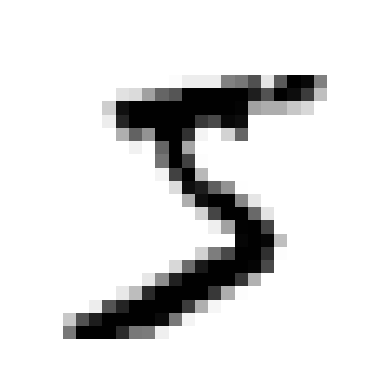

In [96]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [97]:
print(y[0])

5


This looks like a 5, and indeed that’s what the label tells us

Note that the label is a string. Most ML algorithms expect numbers, so let’s cast y to
integer

Creating test and train data

In [98]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Training a Binary Classifier  
Let’s simplify the problem for now and only try to identify one digit—for example,  
the number 5. This “5-detector” will be an example of a binary classifier, capable of  
distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for  
this classification task:

In [99]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [100]:
print(y_train_5)

[ True False False ...  True False False]


A good place to start is with a Stochastic Gradi‐
ent Descent (SGD) classifier,   using Scikit-Learn’s SGDClassifier class.  
 This classifier
has the advantage of being capable of handling very large datasets efficiently.  
 This is
in part because SGD deals with training instances independently, one at a time
(which also makes SGD well suited for online learning)

In [101]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [102]:
sgd_clf.predict([some_digit])


array([ True])

Measuring Accuracy with Cross-Validation in Machine Learning
1. Why We Measure Accuracy

In supervised machine learning, we want to know how well a model generalizes to unseen data. Accuracy is one of the most common metrics:

Accuracy
=
Correct Predictions
Total Predictions
Accuracy=
Total Predictions /
Correct Predictions
	​


But measuring accuracy on the same data used for training gives overly optimistic results. That’s why we split data into training and testing sets.

Limitations of a Single Train-Test Split

A common approach is an 80/20 split: train on 80%, test on 20%.

Problem: the accuracy you get depends on how the data was split.

A “lucky” split may give higher accuracy.

An “unlucky” split may give lower accuracy.

This makes the estimate unstable and unreliable.

Cross-Validation to the Rescue

Cross-validation solves this by systematically rotating the test set:

Step 1: Shuffle the dataset once (to mix samples).

Step 2: Split into k folds (say, 5 or 10). Each fold is an equal chunk of the dataset.

Step 3: Perform k rounds:

In each round, train on 
𝑘
−
1
k−1 folds (80% if k=5).

Test on the remaining fold (20% if k=5).

Record accuracy.

Step 4: Average the accuracies across folds:

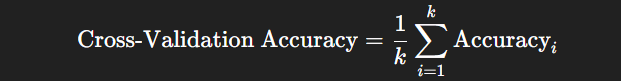

Example: 5-Fold Cross-Validation

Split data into 5 folds: F1, F2, F3, F4, F5.

Round 1: Train on F2–F5, test on F1.

Round 2: Train on F1, F3–F5, test on F2.

… repeat until each fold has been test set once.

Final result = average accuracy of all 5 rounds.

This ensures every sample is used once for testing and 
𝑘
−
1
k−1 times for training.

Why Cross-Validation Accuracy is Good

✅ Uses all data → nothing wasted.  
✅ Less bias → no dependency on a single split.  
✅ More reliable → stable estimate of performance.  
✅ Shows variability → standard deviation tells us if the model is consistent.  

In [103]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Wow! Above 95% accuracy (ratio of correct predictions) on all cross-validation folds?  
 This looks amazing, doesn’t it? Well, before you get too excited, let’s look at a dummy classifier  
  that just classifies every single image in the most frequent class, which in this case is the negative class

In [104]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))  # prints False: no 5s detected

False


In [105]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

That’s right, it has over 90% accuracy! This is simply because only about 10% of the images are 5s,  
 so if you always guess that an image is not a 5, you will be right about 90% of the time. Beats Nostradamus.

This demonstrates why accuracy is generally not the preferred performance measure for classifiers,  
 especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).  
  A much better way to evaluate the performance of a classifier is to look at the confusion matrix (CM).

Implementing Cross-Validation
Occasionally you will need more control over the cross-validation process than what Scikit-Learn provides off the shelf.  
 In these cases, you can implement cross-validation yourself.  
  The following code does roughly the same thing as Scikit-Learn’s cross_val_score() function, and it prints the same result:

In [106]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is
                                       # not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))  # prints 0.95035, 0.96035, and 0.9604

0.95035
0.96035
0.9604
